# Pengambilan Citra Satelit Sentinel-2A Full Jawa Timur (Resolusi 60m)
### Optimasi Cloud openEO CDSE: Komposit Bebas Awan & Anti-OOM (Out-of-Memory)

---

## Ringkasan Proyek
Notebook ini digunakan untuk mengunduh dan memproses citra satelit **Sentinel-2A** yang mencakup **seluruh wilayah Provinsi Jawa Timur** secara stabil dan efisien. Data citra ini dipersiapkan sebagai data masukan (input raster) untuk pemodelan klasifikasi tutupan lahan (5 kelas) berbasis data sampel digitasi GeoJSON.

### Poin Utama & Spesifikasi Teknis:
1. **Cakupan Wilayah (Spatial Extent)**:
   - Mencakup 100% provinsi Jawa Timur (dari ujung barat Ngawi/Pacitan hingga ujung timur Banyuwangi/Madura).
   - Membungkus seluruh sebaran **270 poligon sampel digitasi**.
2. **6 Band Spektral Terpilih**:
   - `B02` (Blue), `B03` (Green), `B04` (Red) : Band spektrum tampak (True Color RGB).
   - `B08` (NIR) & `B8A` (Narrow NIR) : Membedakan kerapatan biomassa klorofil vegetasi.
   - `B11` (SWIR-1) : Membedakan kadar kelembaban/air (sangat efektif memisahkan Hutan Biasa, Mangrove, Sawah, dan Perairan).
3. **Reduksi Temporal (Median Composite)**:
   - Rentang waktu: **1 Agustus 2024 s.d. 31 Agustus 2024** (periode kemarau dengan tutupan awan minimal).
   - Fungsi agregasi `median` menghasilkan komposit citra yang bersih dari tutupan awan.
4. **Strategi Optimasi Cloud (Resampling Spasial 60m)**:
   - Mengurangi volume piksel komputasi dari ~5,1 miliar piksel (pada resolusi 10m) menjadi ~140 juta piksel.
   - Mencegah error **Out of Memory (OOM)** dan **Timeout** pada cluster gratis Copernicus Data Space Ecosystem (CDSE).
   - Waktu pemrosesan cepat (±2 - 4 menit) dengan ukuran file ringan (±35 MB).
5. **Eksekusi Asinkron (Batch Job)**:
   - Proses pengolahan dijalankan langsung pada cloud cluster Copernicus, sehingga tidak membebani memori lokal dan aman dari gangguan koneksi internet lokal.

---
### Alur Pengerjaan (Workflow Pipeline):
1. **Import Library**: Menyiapkan pustaka pengolahan data geospasial dan cloud API.
2. **Membaca Sampel Digitasi**: Memuat 270 poligon GeoJSON (5 kelas) dan menghitung koordinat batas (*bounding box*).
3. **Peta Interaktif Sebaran (Folium)**: Memvisualisasikan sebaran poligon di atas peta satelit Esri World Imagery.
4. **Crawling Citra Satelit (openEO CDSE)**: Menjalankan *batch job* pengunduhan citra Sentinel-2A 6 band resolusi 60m.
5. **Inspeksi Citra GeoTIFF**: Memvalidasi metadata raster, dimensi citra, proyeksi CRS, dan kelengkapan 6 band.
6. **Visualisasi Citra & Tumpukan Poligon**: Menampilkan komposit *True Color RGB* dan *False Color Spektral* beserta sampel poligon.


## 1. Import Library
Memuat seluruh pustaka (*library*) yang dibutuhkan untuk pengolahan data vektor geospasial, komunikasi cloud openEO, manipulasi array raster, serta visualisasi peta.


In [1]:
# ==============================================================================
# 1. IMPORT LIBRARY & PERSIAPAN DIREKTORI
# ==============================================================================

# Pustaka Standar Python
import os
import glob
import time
import json

# Pustaka Pengolahan Data Numerik & Vektor
import numpy as np
import pandas as pd
import geopandas as gpd

# Pustaka Visualisasi Data & Peta
import matplotlib.pyplot as plt
import folium

# Pustaka Pengolahan Citra Raster Satelit
import rasterio
from rasterio.plot import show

# Pustaka Akses Cloud Copernicus Data Space Ecosystem (CDSE)
import openeo

# Memastikan folder penyimpanan output tersedia
os.makedirs("data/tif", exist_ok=True)
os.makedirs("data/images", exist_ok=True)

# Menampilkan konfirmasi impor pustaka
print("Status: Seluruh pustaka berhasil diimpor dengan baik.")
print(f"- Versi openEO   : {openeo.__version__}")
print(f"- Versi GeoPandas: {gpd.__version__}")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", l

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", l

AttributeError: _ARRAY_API not found

Status: Seluruh pustaka berhasil diimpor dengan baik.
- Versi openEO   : 0.51.0
- Versi GeoPandas: 1.0.1


## 2. Membaca 270 Poligon Sampel Digitasi Se-Jawa Timur
Pada tahap ini, kita memuat 5 berkas GeoJSON hasil digitasi sampel tutupan lahan:
- **Bangunan (Built-up)**: 60 poligon
- **Lahan Pertanian (Sawah)**: 60 poligon
- **Perairan (Water Body)**: 50 poligon
- **Hutan Biasa**: 50 poligon
- **Hutan Mangrove**: 50 poligon

Seluruh poligon digabungkan ke dalam satu GeoDataFrame dan dihitung batas terluarnya (*bounding box*) untuk menjadi acuan koordinat *crawling* citra satelit se-Jawa Timur.


In [2]:
# ==============================================================================
# 2. KONFIGURASI DAN PEMBACAAN DATA POLIGON HASIL DIGITASI
# ==============================================================================

# Definisi konfigurasi 5 kelas tutupan lahan: path berkas, label kelas, dan warna visualisasi
class_configs = {
    "building": {
        "file": "data/geojson/building.geojson",
        "label": "Bangunan (Built-up)",
        "color": "#e74c3c",      # Merah Terang
        "fill_color": "#ff7675"  # Coral / Merah Muda
    },
    "sawah": {
        "file": "data/geojson/sawah.geojson",
        "label": "Lahan Pertanian (Sawah)",
        "color": "#f1c40f",      # Kuning Terang (Kontras total dari hutan)
        "fill_color": "#f39c12"  # Oranye Emas
    },
    "perairan": {
        "file": "data/geojson/perairan.geojson",
        "label": "Perairan (Water Body)",
        "color": "#0984e3",      # Biru Samudra
        "fill_color": "#74b9ff"  # Biru Langit Cerah
    },
    "hutan": {
        "file": "data/geojson/Hutan Biasa.geojson",
        "label": "Hutan Biasa",
        "color": "#27ae60",      # Hijau Alami
        "fill_color": "#2ecc71"  # Hijau Daun Terang
    },
    "mangrove": {
        "file": "data/geojson/Mangrove.geojson",
        "label": "Hutan Mangrove",
        "color": "#8e44ad",      # Ungu Royal
        "fill_color": "#a29bfe"  # Ungu Muda / Lavender
    }
}

gdf_list = []
summary_counts = {}

# Membaca masing-masing berkas GeoJSON dan menambahkan label kelas
for key, cfg in class_configs.items():
    if os.path.exists(cfg["file"]):
        gdf_temp = gpd.read_file(cfg["file"])
        gdf_temp["kelas_kode"] = key
        gdf_temp["kelas_nama"] = cfg["label"]
        gdf_list.append(gdf_temp)
        summary_counts[cfg["label"]] = len(gdf_temp)
    else:
        print(f"Peringatan: Berkas {cfg['file']} tidak ditemukan!")

# Menggabungkan seluruh GeoDataFrame menjadi satu tabel geospasial utuh
gdf_all = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True), geometry="geometry", crs="EPSG:4326")

# Menampilkan ringkasan data poligon
print("=== Ringkasan Data Poligon Hasil Digitasi Se-Jawa Timur ===")
for k, v in summary_counts.items():
    print(f"- {k:30s}: {v} poligon")
print(f"Total Poligon: {len(gdf_all)} sampel")

# Menghitung batas terluar (bounding box) seluruh wilayah Jawa Timur dari sebaran poligon
bounds = gdf_all.total_bounds
print()
print("=== Cakupan Wilayah Jawa Timur (Ujung ke Ujung) ===")
print(f"- Ujung Barat   (West)  : {bounds[0]:.4f} (Ngawi / Ponorogo)")
print(f"- Ujung Timur   (East)  : {bounds[2]:.4f} (Banyuwangi / Selat Bali)")
print(f"- Ujung Selatan (South) : {bounds[1]:.4f} (Pesisir Samudra Hindia / Pacitan-Malang)")
print(f"- Ujung Utara   (North) : {bounds[3]:.4f} (Pesisir Laut Jawa / Tuban-Madura)")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", l

AttributeError: _ARRAY_API not found

=== Ringkasan Data Poligon Hasil Digitasi Se-Jawa Timur ===
- Bangunan (Built-up)           : 60 poligon
- Lahan Pertanian (Sawah)       : 60 poligon
- Perairan (Water Body)         : 50 poligon
- Hutan Biasa                   : 50 poligon
- Hutan Mangrove                : 50 poligon
Total Poligon: 270 sampel

=== Cakupan Wilayah Jawa Timur (Ujung ke Ujung) ===
- Ujung Barat   (West)  : 111.1939 (Ngawi / Ponorogo)
- Ujung Timur   (East)  : 114.4611 (Banyuwangi / Selat Bali)
- Ujung Selatan (South) : -8.6005 (Pesisir Samudra Hindia / Pacitan-Malang)
- Ujung Utara   (North) : -6.6565 (Pesisir Laut Jawa / Tuban-Madura)


## 3. Peta Interaktif Sebaran Daerah Digitasi Se-Jawa Timur (Folium)
Peta interaktif ini memvisualisasikan seluruh **270 poligon sampel digitasi** di atas citra satelit asli (*Esri World Imagery*).
- Setiap kelas tutupan lahan ditempatkan pada layer terpisah dengan kontrol centang (*LayerControl*).
- Anda dapat mengaktifkan atau menonaktifkan masing-masing kelas (misalnya hanya melihat layer Sawah atau Mangrove) serta mengklik poligon untuk melihat informasi ID sampel.


In [3]:
# ==============================================================================
# 3. PEMBUATAN PETA INTERAKTIF SEBARAN POLIGON (FOLIUM)
# ==============================================================================

# Menghitung koordinat titik tengah Jawa Timur berdasarkan batas bounding box
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Inisialisasi peta interaktif Folium
m_jatim = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="CartoDB positron")

# Menambahkan layer citra satelit asli dari Esri World Imagery sebagai latar belakang
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Citra Satelit Asli (Esri)"
).add_to(m_jatim)

# Menambahkan poligon per kelas tutupan lahan ke dalam FeatureGroup masing-masing
for key, cfg in class_configs.items():
    subset = gdf_all[gdf_all["kelas_kode"] == key]
    fg = folium.FeatureGroup(name=f"{cfg['label']} ({len(subset)} Poligon)", show=True)
    
    for _, row in subset.iterrows():
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"], fcol=cfg["fill_color"]: {
                "color": col,
                "weight": 2.5,
                "fillColor": fcol,
                "fillOpacity": 0.5
            },
            popup=f"<b>{cfg['label']}</b> (ID: {row.get('no', '-')})"
        ).add_to(fg)
        
    fg.add_to(m_jatim)

# Menambahkan LayerControl untuk memfilter atau mencentang layer yang ingin dilihat
folium.LayerControl(collapsed=False).add_to(m_jatim)

# Menampilkan peta interaktif
m_jatim


## 4. Crawling Citra Satelit Full Jawa Timur (Batch Job Cloud + Resampling 60m)

Pada tahap ini, proses *crawling* citra satelit Sentinel-2A dijalankan melalui cloud **Copernicus Data Space Ecosystem (CDSE)** menggunakan protokol **openEO**:
- **Batas Wilayah (*Spatial Extent*)**: Bounding box Jawa Timur ditambah sedikit buffer (0.05 derajat) agar seluruh wilayah ter-cover secara sempurna.
- **Periode Waktu (*Temporal Extent*)**: 1 - 31 Agustus 2024 (musim kemarau dengan tutupan awan terendah).
- **Reduksi Median**: Mengambil nilai median temporal untuk setiap piksel sehingga bayangan dan awan tereliminasi secara otomatis.
- **Resampling Spasial ke 60 Meter**: Mengurangi beban kalkulasi piksel hingga 36x lipat sehingga pemrosesan bebas dari *Out-of-Memory (OOM)* pada cluster gratis Copernicus.
- **Batch Job Asinkron**: Tugas dikirim ke server CDSE, dipantau status pengerjaannya setiap 15 detik, dan hasilnya otomatis diunduh saat selesai (estimasi waktu: 2-4 menit, ukuran file: ~35 MB).


In [5]:
# ==============================================================================
# 4. PENGAMBILAN CITRA SATELIT FULL JAWA TIMUR (OPENEO BATCH JOB - 60M)
# ==============================================================================

# Lokasi penyimpanan file raster GeoTIFF lokal
tif_file = "data/tif/sentinel2_jatim_60m.tif"

# Batas spatial extent membungkus presisi seluruh poligon Jawa Timur dari ujung ke ujung (+ buffer 0.05°)
jatim_extent = {
    "west": float(bounds[0] - 0.05),
    "south": float(bounds[1] - 0.05),
    "east": float(bounds[2] + 0.05),
    "north": float(bounds[3] + 0.05)
}

print("=== Parameter Crawling Full Jawa Timur (Resampling 60m) ===")
print(f"Batas Wilayah : West={jatim_extent['west']:.4f}, South={jatim_extent['south']:.4f}, East={jatim_extent['east']:.4f}, North={jatim_extent['north']:.4f}")
print("Band          : B02, B03, B04, B08, B8A, B11 (6 Band Lengkap)")
print("Periode Waktu : 1 Agustus 2024 s.d. 31 Agustus 2024 (Median Bebas Awan)")
print("Resolusi      : 60 meter (Optimasi Cloud: Bebas OOM, estimasi 2-4 menit, ~35 MB)")

# Pengecekan: Jika file sudah ada di lokal, tidak perlu mengunduh ulang dari cloud
if os.path.exists(tif_file):
    print(f"\nBerkas TIF sudah tersedia di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
    print("Catatan: Jika ingin mengunduh ulang dari server, silakan hapus berkas tersebut terlebih dahulu.")
else:
    # 1. Menghubungkan ke API openEO CDSE (Copernicus Data Space Ecosystem)
    print("\nMenghubungkan ke openEO CDSE (Copernicus Data Space Ecosystem)...")
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    print("Autentikasi CDSE openEO berhasil!")
    
    bands_selected = ["B02", "B03", "B04", "B08", "B8A", "B11"]
    
    # 2. Memuat koleksi data Sentinel-2A L2A
    s2 = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=jatim_extent,
        temporal_extent=["2024-08-01", "2024-08-31"],
        bands=bands_selected
    )
    
    # 3. Reduksi median temporal (menghasilkan citra komposit bebas tutupan awan)
    s2_median = s2.reduce_dimension(dimension="t", reducer="median")
    
    # 4. Resampling spasial ke 60 meter (Anti Out-of-Memory di cluster cloud Copernicus)
    s2_resampled = s2_median.resample_spatial(resolution=60)
    
    # 5. Membuat Batch Job di Cloud Copernicus CDSE
    print("\nMembuat Batch Job di server Copernicus (resolusi 60m, estimasi 2-4 menit)...")
    job = s2_resampled.create_job(
        title="Sentinel2_Full_Jatim_60m_6Bands",
        description="Crawling Sentinel-2A Full Jawa Timur 60m untuk 5 kelas tutupan lahan"
    )
    job.start_job()
    print(f"Batch Job berhasil diluncurkan! ID Job: {job.job_id}")
    print("Server Copernicus sedang memproses data di cloud...")
    
    # 6. Memantau status pemrosesan pekerjaan secara berkala setiap 15 detik
    status = job.status()
    detik_berjalan = 0
    while status in ["created", "queued", "running"]:
        print(f"[{detik_berjalan}s] Status pekerjaan di server: {status}... (mengecek lagi dalam 15 detik)")
        time.sleep(15)
        detik_berjalan += 15
        status = job.status()
        
    # 7. Mengunduh hasil GeoTIFF setelah pemrosesan selesai
    if status == "finished":
        print("\nPekerjaan selesai sukses di server cloud! Mengunduh berkas GeoTIFF ke laptop...")
        results = job.get_results()
        results.download_file(tif_file)
        print(f"Pengunduhan selesai! File TIF disimpan di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
    else:
        print(f"\nPekerjaan berhenti dengan status: {status}")
        print("Detail log server Copernicus:")
        try:
            for entry in job.logs():
                print(f"- [{entry.get('level', 'INFO')}] {entry.get('message', '')}")
        except Exception as e:
            print(f"Tidak dapat membaca log: {e}")


=== Parameter Crawling Full Jawa Timur (Resampling 60m) ===
Batas Wilayah : West=111.1439, South=-8.6505, East=114.5111, North=-6.6065
Band          : B02, B03, B04, B08, B8A, B11 (6 Band Lengkap)
Periode Waktu : 1 Agustus 2024 s.d. 31 Agustus 2024 (Median Bebas Awan)
Resolusi      : 60 meter (Optimasi Cloud: Bebas OOM, estimasi 2-4 menit, ~35 MB)

Berkas TIF sudah tersedia di: data/tif/sentinel2_jatim_60m.tif (257.14 MB)
Catatan: Jika ingin mengunduh ulang dari server, silakan hapus berkas tersebut terlebih dahulu.


## 5. Inspeksi Citra GeoTIFF Hasil Crawling (60m)
Pada tahap ini, kita memverifikasi berkas GeoTIFF hasil unduhan menggunakan pustaka `rasterio`:
- Memeriksa nama berkas, ukuran penyimpanan di disk, dimensi piksel, jumlah band spektral, sistem proyeksi (*CRS*), dan koordinat batas (*bounds*).
- Memuat keenam band spektral ke dalam memori array NumPy (`b2`, `b3`, `b4`, `b8`, `b8a`, `b11`) sebagai tipe `float` untuk keperluan visualisasi dan analisis data spektral.


In [6]:
# ==============================================================================
# 5. INSPEKSI METADATA DAN PEMBACAAN BAND CITRA RASTER
# ==============================================================================

if os.path.exists(tif_file):
    with rasterio.open(tif_file) as src:
        print("=== Metadata Berkas GeoTIFF Sentinel-2A ===")
        print(f"Nama Berkas      : {tif_file}")
        print(f"Ukuran Berkas    : {os.path.getsize(tif_file) / (1024*1024):.2f} MB")
        print(f"Dimensi Raster   : {src.width} x {src.height} piksel")
        print(f"Jumlah Band      : {src.count} band")
        print(f"Sistem Koordinat : {src.crs}")
        print(f"Batas BoundingBox: {src.bounds}")
        
        # Membaca seluruh 6 band spektral ke dalam array NumPy (tipe float)
        b2 = src.read(1).astype(float)    # Band 2: Blue (Biru)
        b3 = src.read(2).astype(float)    # Band 3: Green (Hijau)
        b4 = src.read(3).astype(float)    # Band 4: Red (Merah)
        b8 = src.read(4).astype(float)    # Band 8: NIR (Inframerah Dekat)
        b8a = src.read(5).astype(float)   # Band 8A: Narrow NIR (Vegetasi Padat)
        b11 = src.read(6).astype(float)   # Band 11: SWIR-1 (Inframerah Gelombang Pendek / Kelembaban)
        
    print("\nStatus: Seluruh 6 band (B02, B03, B04, B08, B8A, B11) berhasil dimuat ke memori!")
else:
    print(f"Peringatan: Berkas {tif_file} belum ada. Jalankan Sel 4 untuk mengunduh citra dari server Copernicus.")


=== Metadata Berkas GeoTIFF Sentinel-2A ===
Nama Berkas      : data/tif/sentinel2_jatim_60m.tif
Ukuran Berkas    : 257.14 MB
Dimensi Raster   : 6210 x 3797 piksel
Jumlah Band      : 6 band
Sistem Koordinat : EPSG:32749
Batas BoundingBox: BoundingBox(left=515820.0, bottom=9041940.0, right=888420.0, top=9269760.0)

Status: Seluruh 6 band (B02, B03, B04, B08, B8A, B11) berhasil dimuat ke memori!


## 6. Visualisasi Citra Satelit Full Jawa Timur & Tumpukan Poligon Digitasi (5 Kelas)

Pada tahap visualisasi ini, ditampilkan dua komposit citra satelit berdampingan beserta hamparan (**overlay**) **270 poligon sampel digitasi 5 kelas tutupan lahan**:

### 1. Peta 1: True Color RGB (Band 4 - Band 3 - Band 2)
- Menampilkan kenampakan permukaan bumi sesuai warna alami yang ditangkap mata manusia:
  - **Air / Laut**: Biru Gelap
  - **Bangunan / Area Terbangun**: Abu-abu Terang / Putih
  - **Lahan Pertanian (Sawah)**: Hijau Muda Alami
  - **Hutan**: Hijau Tua Pekat

### 2. Peta 2: False Color Spektral (Band 8A - Band 11 - Band 4)
- Menggabungkan band Narrow NIR (`B8A`), SWIR-1 (`B11`), dan Red (`B04`) untuk menghasilkan pembedaan kontras spektral yang sangat tajam bagi seluruh kelas:
  - **Perairan (Water Body)**: Hitam Pekat (karena air menyerap penuh gelombang inframerah).
  - **Bangunan (Built-up)**: Cyan / Abu-abu Terang (reflektansi kuat gelombang SWIR dan Red dari atap bangunan, semen, aspal).
  - **Lahan Pertanian (Sawah)**: Kuning Keemasan / Oranye (vegetasi musiman dengan respon air dan biomassa).
  - **Hutan Biasa**: Merah Terang Menyala (kanopi lebat pepohonan kaya klorofil memantulkan kuat NIR).
  - **Hutan Mangrove**: Merah Marun Gelap (karakter vegetasi khas pesisir/muara dengan substrat basah/berair).

Kedua peta dilengkapi dengan batas proyeksi raster (*img_extent*) berkoordinat UTM Zone 49S (meter) dan legenda 5 kelas tutupan lahan.


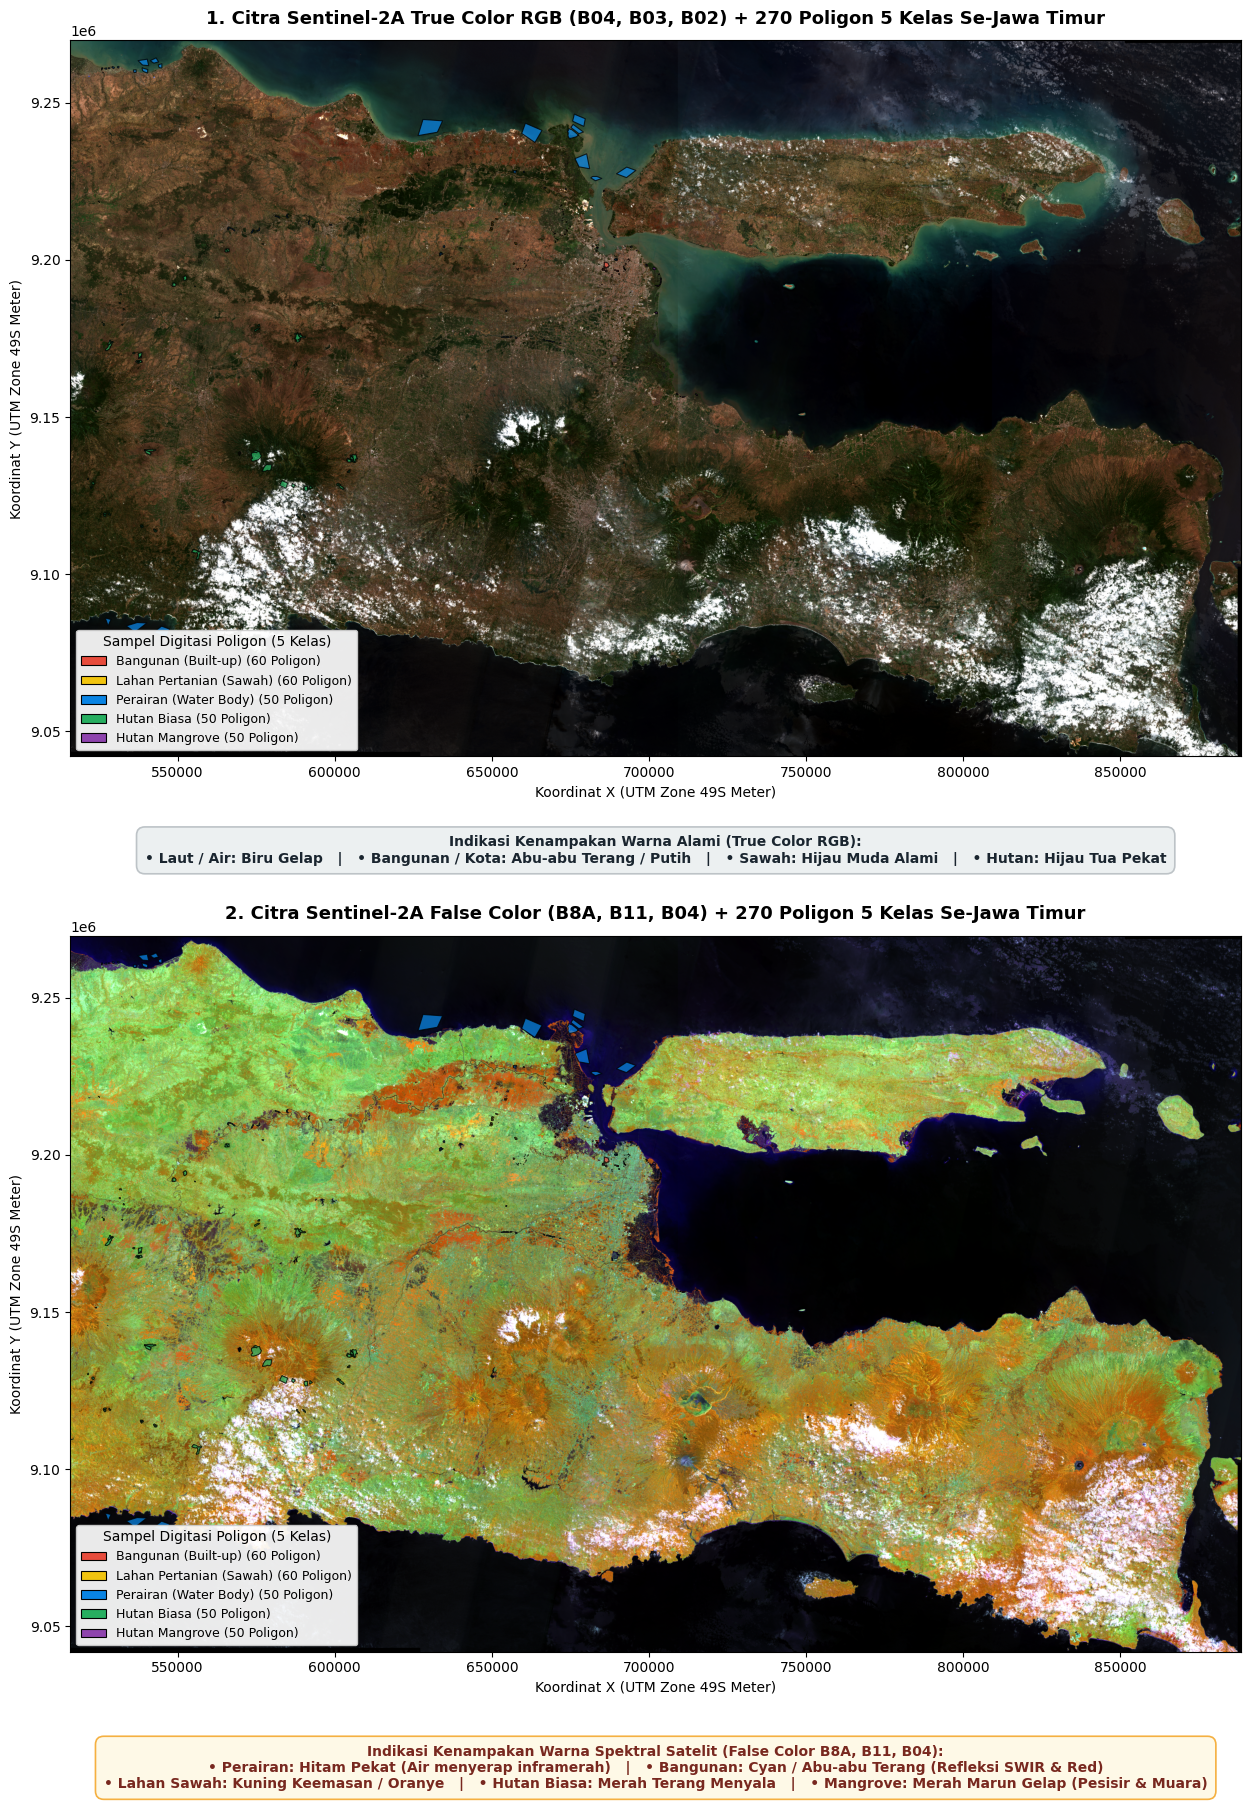

Visualisasi citra satelit Full Jawa Timur (True Color & False Color) dengan indikasi warna di bawahnya berhasil ditampilkan dan disimpan!


In [7]:
# ==============================================================================
# 6. VISUALISASI CITRA TRUE COLOR & FALSE COLOR DENGAN POLIGON 5 KELAS
# ==============================================================================

if os.path.exists(tif_file):
    import matplotlib.patches as mpatches

    # Fungsi penyesuaian kontras citra raster (Percentile Stretch 2% - 98%)
    def stretch(band):
        valid = band[band > 0]
        if len(valid) == 0:
            return np.zeros_like(band)
        p2, p98 = np.percentile(valid, (2, 98))
        return np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)

    # 1. Komposit True Color RGB (B04, B03, B02) - Kenampakan Warna Alami
    rgb_jatim = np.dstack([stretch(b4), stretch(b3), stretch(b2)])

    # 2. Komposit False Color Spektral (B8A, B11, B04) - Kontras Spektral 5 Kelas
    false_jatim = np.dstack([stretch(b8a), stretch(b11), stretch(b4)])

    # Mengambil koordinat batas langsung dari rasterio untuk akurasi posisi 100%
    with rasterio.open(tif_file) as src:
        img_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        raster_crs = src.crs

    # Memastikan poligon GeoDataFrame berada dalam sistem proyeksi yang sama dengan raster (UTM Zone 49S)
    gdf_plot = gdf_all.to_crs(raster_crs) if gdf_all.crs != raster_crs else gdf_all

    fig, axes = plt.subplots(2, 1, figsize=(16, 18))

    # Membuat legend patches berwarna untuk 5 kelas sampel digitasi
    legend_handles = [
        mpatches.Patch(facecolor=cfg["color"], edgecolor="black", linewidth=0.8,
                       label=f"{cfg['label']} ({summary_counts.get(cfg['label'], 0)} Poligon)")
        for key, cfg in class_configs.items()
    ]

    # --- PETA 1: TRUE COLOR RGB + POLIGON 5 KELAS ---
    axes[0].imshow(rgb_jatim, extent=img_extent)
    axes[0].set_title("1. Citra Sentinel-2A True Color RGB (B04, B03, B02) + 270 Poligon 5 Kelas Se-Jawa Timur", fontsize=13, fontweight="bold", pad=12)
    axes[0].set_xlabel("Koordinat X (UTM Zone 49S Meter)", fontsize=10)
    axes[0].set_ylabel("Koordinat Y (UTM Zone 49S Meter)", fontsize=10)

    for key, cfg in class_configs.items():
        subset = gdf_plot[gdf_plot["kelas_kode"] == key]
        subset.plot(ax=axes[0], color=cfg["color"], edgecolor="black", linewidth=0.8, alpha=0.75)

    axes[0].legend(handles=legend_handles, loc="lower left", framealpha=0.92, title="Sampel Digitasi Poligon (5 Kelas)", fontsize=9, title_fontsize=10)

    # Kotak Indikasi Warna di Bawah Peta 1
    info_peta1 = (
        "Indikasi Kenampakan Warna Alami (True Color RGB):\n"
        "• Laut / Air: Biru Gelap   |   • Bangunan / Kota: Abu-abu Terang / Putih   |   • Sawah: Hijau Muda Alami   |   • Hutan: Hijau Tua Pekat"
    )
    axes[0].text(
        0.5, -0.11, info_peta1,
        transform=axes[0].transAxes,
        ha="center", va="top",
        fontsize=10, fontweight="semibold",
        color="#1a252f",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#ecf0f1", edgecolor="#bdc3c7", linewidth=1.2)
    )

    # --- PETA 2: FALSE COLOR (B8A, B11, B04) + POLIGON 5 KELAS ---
    axes[1].imshow(false_jatim, extent=img_extent)
    axes[1].set_title("2. Citra Sentinel-2A False Color (B8A, B11, B04) + 270 Poligon 5 Kelas Se-Jawa Timur", fontsize=13, fontweight="bold", pad=12)
    axes[1].set_xlabel("Koordinat X (UTM Zone 49S Meter)", fontsize=10)
    axes[1].set_ylabel("Koordinat Y (UTM Zone 49S Meter)", fontsize=10)

    for key, cfg in class_configs.items():
        subset = gdf_plot[gdf_plot["kelas_kode"] == key]
        subset.plot(ax=axes[1], color=cfg["color"], edgecolor="black", linewidth=0.8, alpha=0.75)

    axes[1].legend(handles=legend_handles, loc="lower left", framealpha=0.92, title="Sampel Digitasi Poligon (5 Kelas)", fontsize=9, title_fontsize=10)

    # Kotak Indikasi Warna di Bawah Peta 2
    info_peta2 = (
        "Indikasi Kenampakan Warna Spektral Satelit (False Color B8A, B11, B04):\n"
        "• Perairan: Hitam Pekat (Air menyerap inframerah)   |   • Bangunan: Cyan / Abu-abu Terang (Refleksi SWIR & Red)\n"
        "• Lahan Sawah: Kuning Keemasan / Oranye   |   • Hutan Biasa: Merah Terang Menyala   |   • Mangrove: Merah Marun Gelap (Pesisir & Muara)"
    )
    axes[1].text(
        0.5, -0.13, info_peta2,
        transform=axes[1].transAxes,
        ha="center", va="top",
        fontsize=10, fontweight="semibold",
        color="#78281f",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#fef9e7", edgecolor="#f5b041", linewidth=1.2)
    )

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)
    os.makedirs("data/images", exist_ok=True)
    plt.savefig("data/images/visualisasi_full_jatim_60m.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Visualisasi citra satelit Full Jawa Timur (True Color & False Color) dengan indikasi warna di bawahnya berhasil ditampilkan dan disimpan!")
else:
    print("Silakan unduh citra pada Sel 4 terlebih dahulu.")
